# Etapa 6 — ITUB4 com 17 anos de notícias (2009–2026)

Pipeline completo: FinBERT sentiment → merge com preços → treinamento dos 4 modelos.

**Dados:** 12.891 artigos do InfoMoney (2009-06 a 2026-01)
**Hipótese:** mais dados de treino (~5x) deve estabilizar os modelos e melhorar generalização.

## 1. Extração de Sentimento FinBERT

In [14]:
import json
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, BertForSequenceClassification

model_dir = '../4.finbert-br/FinBERT-PT-BR'
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = BertForSequenceClassification.from_pretrained(model_dir)
model.eval()

LABEL_MAP = {0: 'POSITIVE', 1: 'NEGATIVE', 2: 'NEUTRAL'}
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(f'Device: {device}')

# Load 17-year news
with open('itub4_noticias.json', 'r') as f:
    articles = json.load(f)
print(f'Articles: {len(articles)}')
print(f'Period: {articles[-1]["date"][:10]} to {articles[0]["date"][:10]}')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11962.98it/s]
BertForSequenceClassification LOAD REPORT from: ../4.finbert-br/FinBERT-PT-BR
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Articles: 12891
Period: 2009-06-24 to 2026-01-26


In [15]:
def predict_batch(texts, batch_size=32):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tokens = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=512).to(device)
        with torch.no_grad():
            logits = model(**tokens).logits.cpu().numpy()
        for log in logits:
            cls = int(np.argmax(log))
            results.append({
                'sentiment_class': cls,
                'sentiment': LABEL_MAP[cls],
                'logits': log.tolist(),
            })
    return results

texts = [f"{a['title']}. {a['excerpt']}" for a in articles]
print(f'Processing {len(texts)} articles...')
preds = predict_batch(texts, batch_size=32)

# Enrich articles
for article, pred in zip(articles, preds):
    article['sentiment'] = pred['sentiment']
    article['sentiment_class'] = pred['sentiment_class']
    article['sentiment_logits'] = pred['logits']

sentiments = [p['sentiment'] for p in preds]
print(f"POSITIVE: {sentiments.count('POSITIVE')} ({sentiments.count('POSITIVE')/len(sentiments)*100:.1f}%)")
print(f"NEGATIVE: {sentiments.count('NEGATIVE')} ({sentiments.count('NEGATIVE')/len(sentiments)*100:.1f}%)")
print(f"NEUTRAL:  {sentiments.count('NEUTRAL')} ({sentiments.count('NEUTRAL')/len(sentiments)*100:.1f}%)")

Processing 12891 articles...
POSITIVE: 3386 (26.3%)
NEGATIVE: 5469 (42.4%)
NEUTRAL:  4036 (31.3%)


In [16]:
# Daily sentiment aggregation
df_sent = pd.DataFrame([{
    'date': a['date'][:10],
    'sentiment_class': a['sentiment_class'],
    'logit_pos': a['sentiment_logits'][0],
    'logit_neg': a['sentiment_logits'][1],
    'logit_neu': a['sentiment_logits'][2],
} for a in articles])

df_sent['date'] = pd.to_datetime(df_sent['date'])

daily = df_sent.groupby('date').agg(
    n_articles=('sentiment_class', 'count'),
    mean_logit_pos=('logit_pos', 'mean'),
    mean_logit_neg=('logit_neg', 'mean'),
    mean_logit_neu=('logit_neu', 'mean'),
    mean_sentiment=('sentiment_class', 'mean'),
).sort_index()

daily.to_csv('itub4_daily_sentiment_17y.csv')
print(f'Daily sentiment: {len(daily)} days')
print(f'Period: {daily.index[0].date()} to {daily.index[-1].date()}')
display(daily.describe())

Daily sentiment: 3807 days
Period: 2009-06-05 to 2026-03-26


,n_articles,mean_logit_pos,mean_logit_neg,mean_logit_neu,mean_sentiment
count,3807.000000,3807.000000,3807.000000,3807.000000,3807.000000
mean,3.386131,-0.846376,-0.356526,-0.937167,0.969270
std,2.819513,0.884524,1.136344,0.631593,0.526415
min,1.000000,-2.298754,-2.445036,-2.024437,0.000000
25%,1.000000,-1.591398,-1.314585,-1.486733,0.666667
50%,3.000000,-0.997182,-0.486350,-1.000865,1.000000
75%,4.000000,-0.343057,0.447740,-0.515850,1.333333
max,44.000000,1.866984,1.814711,1.170751,2.000000


## 2. Construção do Dataset

In [17]:
import sys
import importlib

sys.path.insert(0, '../2.stocks')
sys.path.insert(0, '../3.model_traning')

# Force reload local module (pip package shadows it)
if 'yahoo_finance' in sys.modules:
    del sys.modules['yahoo_finance']

from yahoo_finance import MarketData
md = MarketData('ITUB4.SA')
X_prices = md.features(lags=5)
print(f'Price data: {X_prices.shape}, {X_prices.index[0].date()} to {X_prices.index[-1].date()}')

# Merge with sentiment
sentiment = pd.read_csv('itub4_daily_sentiment_17y.csv', index_col=0, parse_dates=True)
X_combined = X_prices.join(sentiment, how='left')
sent_cols = sentiment.columns.tolist()
X_combined[sent_cols] = X_combined[sent_cols].ffill()
X_combined = X_combined.dropna()

print(f'\nCombined dataset: {X_combined.shape}')
print(f'Period: {X_combined.index[0].date()} to {X_combined.index[-1].date()}')
print(f'Features: {X_combined.columns.tolist()}')

# Compare with Etapa 4
print(f'\n--- Comparação ---')
print(f'Etapa 4 (5 anos):  1.227 dias × 16 features')
print(f'Etapa 6 (17 anos): {X_combined.shape[0]} dias × {X_combined.shape[1]} features')

Price data: (6313, 11), 2001-01-18 to 2026-03-27

Combined dataset: (4176, 16)
Period: 2009-06-05 to 2026-03-27
Features: ['Close', 'Volume', 'return', 'ma7', 'ma21', 'std21', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment']

--- Comparação ---
Etapa 4 (5 anos):  1.227 dias × 16 features
Etapa 6 (17 anos): 4176 dias × 16 features


In [20]:
from collections import Counter

In [26]:
print(f'SOBE: {Counter(y)[1] / len(y)}')
print(f'Desce: {Counter(y)[0] / len(y)}')

SOBE: 0.5687272727272727
Desce: 0.43127272727272725


## 3. Preparação e Treinamento

In [5]:
from lstm_classifier import build_dataset

X_seq, y, dates, features, scaler = build_dataset(
    X_combined, horizon=21, pca_components=32, window=30,
)

print(f'Sequences: {X_seq.shape}')
print(f'Balance: {y.mean():.1%} sobe / {1-y.mean():.1%} desce')

12:25:57 [INFO] Shape de entrada: (4176, 16)
12:25:57 [INFO] Distribuição do target: {1: 2370, 0: 1785}  (balance: 57.0% sobe)
12:25:57 [INFO] Features finais: 16
12:25:57 [INFO] Sequências geradas: (4125, 30, 16)  →  y: (4125,)


Sequences: (4125, 30, 16)
Balance: 56.9% sobe / 43.1% desce


In [6]:
from lstm_classifier import train, evaluate, plot_results
from xgboost_baseline import build_flat_dataset, train_xgboost, evaluate_xgboost, plot_roc
from transformer_classifier import train_transformer, evaluate_transformer, plot_transformer_results

print('=== BiLSTM Original (2L/128h) ===')
model_orig, hist_orig, test_idx_orig, device = train(
    X_seq, y, dates, hidden_size=128, n_layers=2, dropout=0.3, epochs=50, patience=10)
probs_orig, preds_orig, y_test_orig = evaluate(model_orig, X_seq, y, test_idx_orig, dates, device)

print('\n=== BiLSTM Reduzido (1L/64h) ===')
model_red, hist_red, test_idx_red, _ = train(
    X_seq, y, dates, hidden_size=64, n_layers=1, dropout=0.2, epochs=50, patience=10)
probs_red, preds_red, y_test_red = evaluate(model_red, X_seq, y, test_idx_red, dates, device)

print('\n=== XGBoost ===')
X_flat, y_flat, dates_flat, features_flat = build_flat_dataset(X_combined, horizon=21, pca_components=32)
xgb_model, X_test_xgb, y_test_xgb, test_dates_xgb = train_xgboost(X_flat, y_flat, dates_flat)
probs_xgb, preds_xgb, auc_xgb = evaluate_xgboost(xgb_model, X_test_xgb, y_test_xgb)

print('\n=== Transformer ===')
tf_model, hist_tf, test_idx_tf, _ = train_transformer(
    X_seq, y, dates, d_model=64, nhead=4, n_layers=2, dropout=0.3, epochs=50, patience=10)
probs_tf, preds_tf, y_test_tf, auc_tf = evaluate_transformer(
    tf_model, X_seq, y, test_idx_tf, dates, device)

12:25:57 [INFO] Split — treino: 2887 | val: 618 | teste: 620
12:25:57 [INFO] Treino: 2009-07-20 → 2021-03-11
12:25:57 [INFO] Val:    2021-03-12 → 2023-08-30
12:25:57 [INFO] Teste:  2023-08-31 → 2026-02-26
12:25:57 [INFO] Device: cuda


=== BiLSTM Original (2L/128h) ===


12:25:59 [INFO] Epoch   1/50 | loss 0.6942 | val_loss 0.6901 | val_acc 59.2% | lr 1.00e-03
12:25:59 [INFO] Epoch   2/50 | loss 0.6878 | val_loss 0.6861 | val_acc 56.3% | lr 1.00e-03
12:26:00 [INFO] Epoch   3/50 | loss 0.6860 | val_loss 0.6846 | val_acc 55.7% | lr 1.00e-03
12:26:01 [INFO] Epoch   4/50 | loss 0.6859 | val_loss 0.6849 | val_acc 55.8% | lr 1.00e-03
12:26:01 [INFO] Epoch   5/50 | loss 0.6836 | val_loss 0.6784 | val_acc 57.1% | lr 1.00e-03
12:26:02 [INFO] Epoch   6/50 | loss 0.6832 | val_loss 0.6806 | val_acc 57.0% | lr 1.00e-03
12:26:03 [INFO] Epoch   7/50 | loss 0.6833 | val_loss 0.6755 | val_acc 58.9% | lr 1.00e-03
12:26:03 [INFO] Epoch   8/50 | loss 0.6817 | val_loss 0.6725 | val_acc 59.2% | lr 1.00e-03
12:26:04 [INFO] Epoch   9/50 | loss 0.6781 | val_loss 0.6668 | val_acc 59.5% | lr 1.00e-03
12:26:05 [INFO] Epoch  10/50 | loss 0.6766 | val_loss 0.6547 | val_acc 62.1% | lr 1.00e-03
12:26:05 [INFO] Epoch  11/50 | loss 0.6735 | val_loss 0.6583 | val_acc 61.0% | lr 1.00e-03


=== BiLSTM Reduzido (1L/64h) ===


12:26:15 [INFO] Epoch   1/50 | loss 0.6897 | val_loss 0.6894 | val_acc 56.6% | lr 1.00e-03
12:26:15 [INFO] Epoch   2/50 | loss 0.6843 | val_loss 0.6867 | val_acc 57.8% | lr 1.00e-03
12:26:16 [INFO] Epoch   3/50 | loss 0.6815 | val_loss 0.6813 | val_acc 58.1% | lr 1.00e-03
12:26:16 [INFO] Epoch   4/50 | loss 0.6800 | val_loss 0.6723 | val_acc 58.3% | lr 1.00e-03
12:26:17 [INFO] Epoch   5/50 | loss 0.6768 | val_loss 0.6641 | val_acc 60.7% | lr 1.00e-03
12:26:17 [INFO] Epoch   6/50 | loss 0.6732 | val_loss 0.6609 | val_acc 60.4% | lr 1.00e-03
12:26:18 [INFO] Epoch   7/50 | loss 0.6689 | val_loss 0.6542 | val_acc 60.8% | lr 1.00e-03
12:26:18 [INFO] Epoch   8/50 | loss 0.6745 | val_loss 0.6478 | val_acc 62.0% | lr 1.00e-03
12:26:19 [INFO] Epoch   9/50 | loss 0.6681 | val_loss 0.6620 | val_acc 59.4% | lr 1.00e-03
12:26:19 [INFO] Epoch  10/50 | loss 0.6546 | val_loss 0.6550 | val_acc 60.4% | lr 1.00e-03
12:26:20 [INFO] Epoch  11/50 | loss 0.6646 | val_loss 0.6522 | val_acc 60.4% | lr 1.00e-03


=== XGBoost ===

=== Transformer ===


12:26:25 [INFO] Epoch   1/50 | loss 0.7008 | val_loss 0.6852 | val_acc 53.1% | lr 1.00e-03
12:26:26 [INFO] Epoch   2/50 | loss 0.6992 | val_loss 0.6846 | val_acc 53.2% | lr 1.00e-03
12:26:26 [INFO] Epoch   3/50 | loss 0.6848 | val_loss 0.6583 | val_acc 60.4% | lr 1.00e-03
12:26:27 [INFO] Epoch   4/50 | loss 0.6924 | val_loss 0.6975 | val_acc 53.2% | lr 1.00e-03
12:26:28 [INFO] Epoch   5/50 | loss 0.6840 | val_loss 0.6772 | val_acc 61.2% | lr 1.00e-03
12:26:29 [INFO] Epoch   6/50 | loss 0.7030 | val_loss 0.6898 | val_acc 54.5% | lr 1.00e-03
12:26:30 [INFO] Epoch   7/50 | loss 0.6783 | val_loss 0.6771 | val_acc 59.7% | lr 1.00e-03
12:26:31 [INFO] Epoch   8/50 | loss 0.6834 | val_loss 0.6865 | val_acc 59.2% | lr 1.00e-03
12:26:32 [INFO] Epoch   9/50 | loss 0.6856 | val_loss 0.6671 | val_acc 58.4% | lr 5.00e-04
12:26:33 [INFO] Epoch  10/50 | loss 0.6768 | val_loss 0.6568 | val_acc 62.8% | lr 5.00e-04
12:26:33 [INFO] Epoch  11/50 | loss 0.6930 | val_loss 0.6585 | val_acc 61.3% | lr 5.00e-04

## 4. Tabela Comparativa

In [7]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

results = {
    'BiLSTM Original (2L/128h)': {'probs': probs_orig, 'preds': preds_orig, 'y_test': y_test_orig},
    'BiLSTM Reduzido (1L/64h)': {'probs': probs_red, 'preds': preds_red, 'y_test': y_test_red},
    'XGBoost': {'probs': probs_xgb, 'preds': preds_xgb, 'y_test': y_test_xgb},
    'Transformer': {'probs': probs_tf, 'preds': preds_tf, 'y_test': y_test_tf},
}

rows = []
for name, r in results.items():
    rows.append({
        'Modelo': name,
        'ROC-AUC': roc_auc_score(r['y_test'], r['probs']),
        'Accuracy': accuracy_score(r['y_test'], r['preds']),
        'F1 (Sobe)': f1_score(r['y_test'], r['preds'], zero_division=0),
    })

df_results = pd.DataFrame(rows).set_index('Modelo')
display(df_results.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen'))

# Compare with Etapa 4
print('\n--- Comparação com Etapa 4 (5 anos, 1.227 dias) ---')
etapa4 = {
    'BiLSTM Original (2L/128h)': 0.500,
    'BiLSTM Reduzido (1L/64h)': 0.477,
    'XGBoost': 0.670,
    'Transformer': 0.709,
}
for name, r in results.items():
    auc_new = roc_auc_score(r['y_test'], r['probs'])
    auc_old = etapa4[name]
    delta = auc_new - auc_old
    print(f'  {name}: {auc_old:.3f} -> {auc_new:.3f} ({delta:+.3f})')

,ROC-AUC,Accuracy,F1 (Sobe)
Modelo,,,
BiLSTM Original (2L/128h),0.5307,0.4258,0.2764
BiLSTM Reduzido (1L/64h),0.5215,0.3774,0.1147
XGBoost,0.5113,0.3478,0.0000
Transformer,0.6160,0.3919,0.1490



--- Comparação com Etapa 4 (5 anos, 1.227 dias) ---
  BiLSTM Original (2L/128h): 0.500 -> 0.531 (+0.031)
  BiLSTM Reduzido (1L/64h): 0.477 -> 0.522 (+0.045)
  XGBoost: 0.670 -> 0.511 (-0.159)
  Transformer: 0.709 -> 0.616 (-0.093)


## 5. Curvas ROC Comparativas

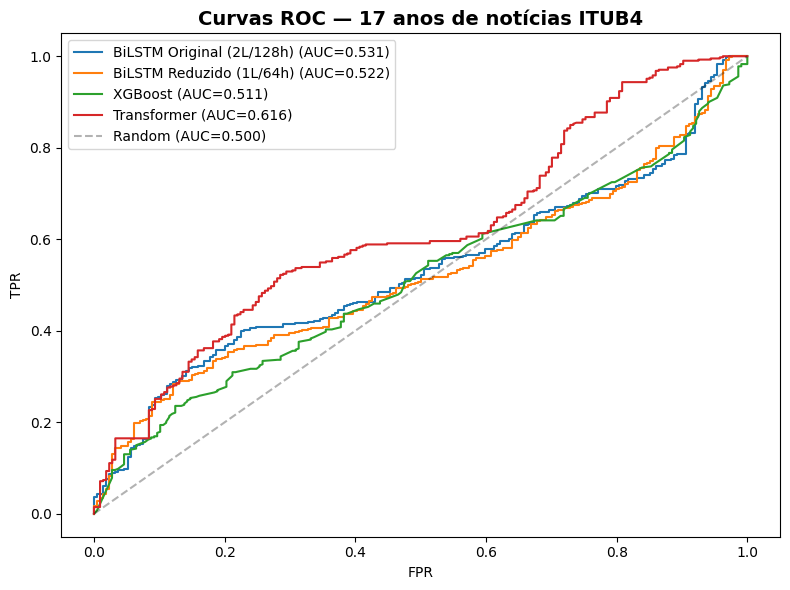

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(r['y_test'], r['probs'])
    auc = roc_auc_score(r['y_test'], r['probs'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.500)')
ax.set_title('Curvas ROC — 17 anos de notícias ITUB4', fontsize=14, fontweight='bold')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
plt.tight_layout()
plt.savefig('roc_17years.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Gráficos de Treino

12:26:43 [INFO] Gráfico salvo em lstm_results.png


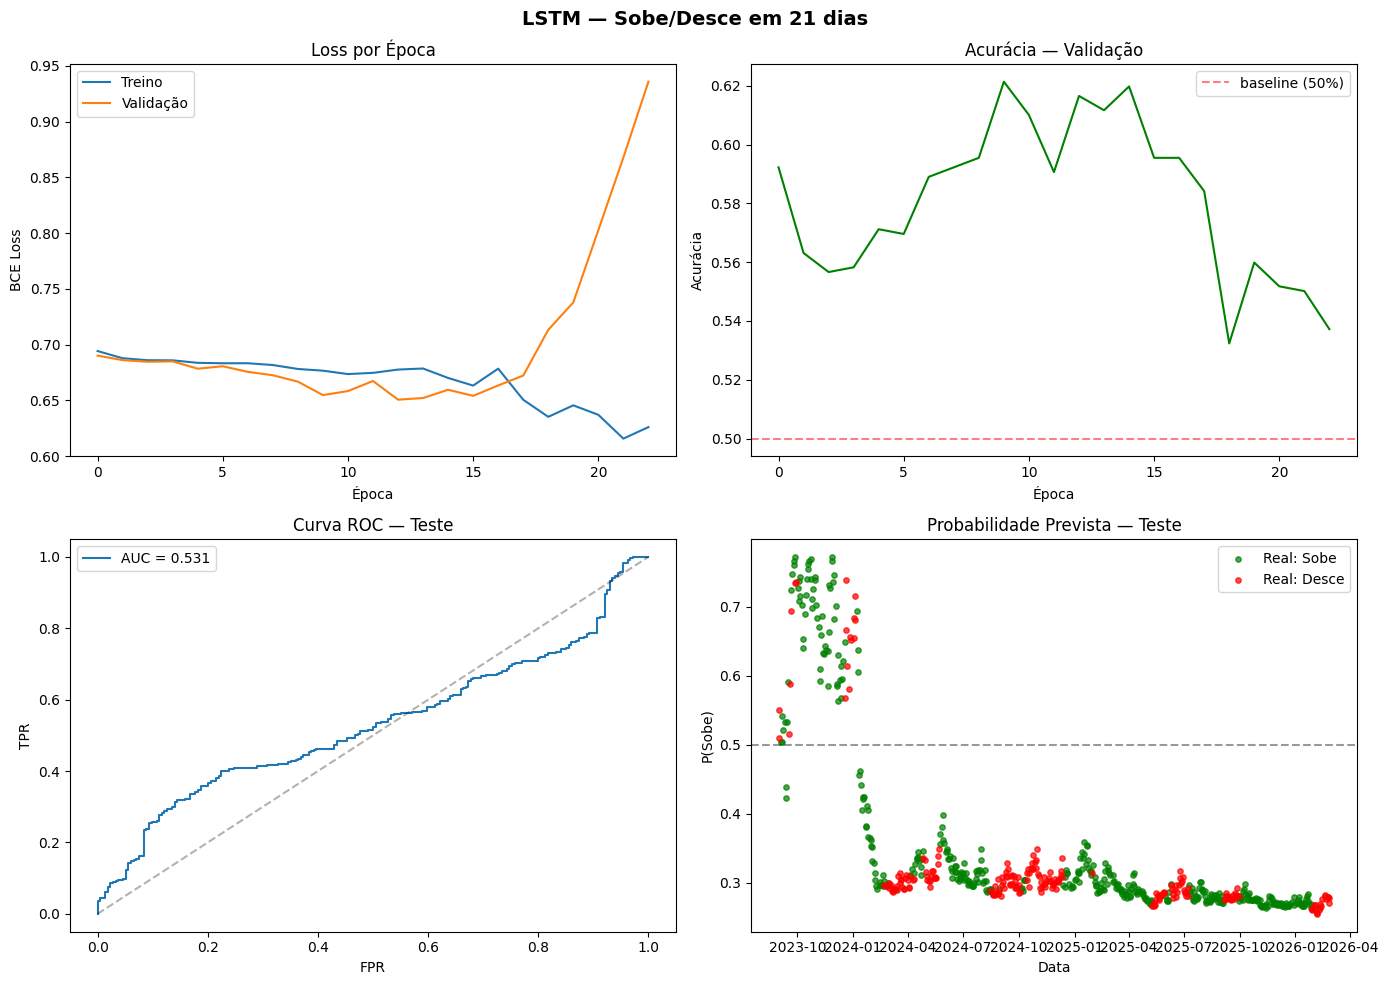

In [9]:
plot_results(hist_orig, probs_orig, preds_orig, y_test_orig, dates, test_idx_orig)

12:26:44 [INFO] Gráfico salvo em lstm_results.png


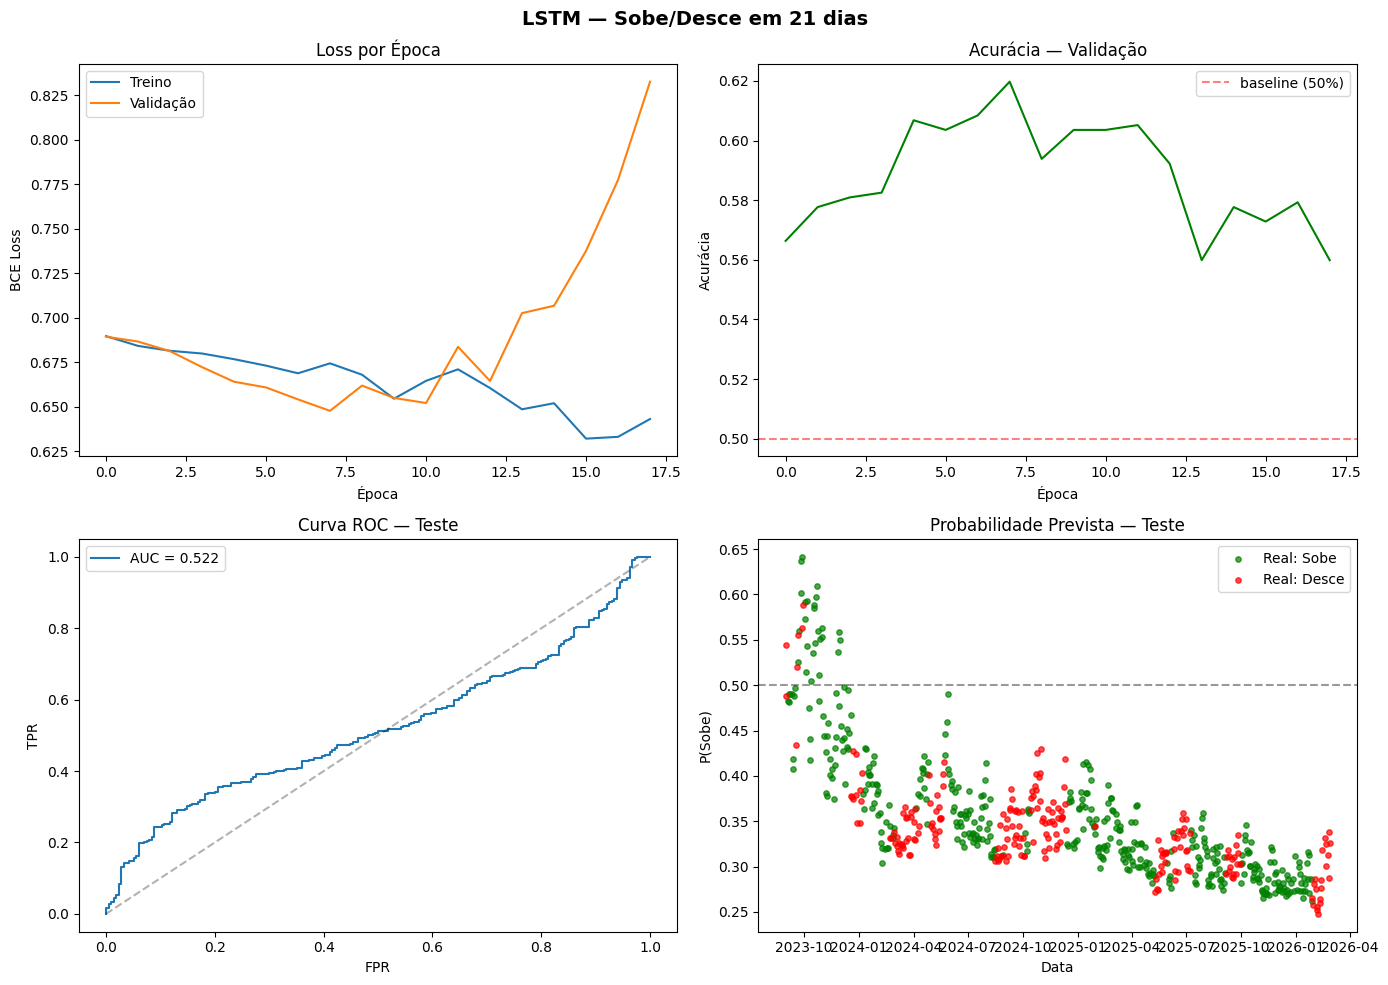

In [10]:
plot_results(hist_red, probs_red, preds_red, y_test_red, dates, test_idx_red)

12:26:45 [INFO] Curva ROC salva em xgboost_roc_17y.png


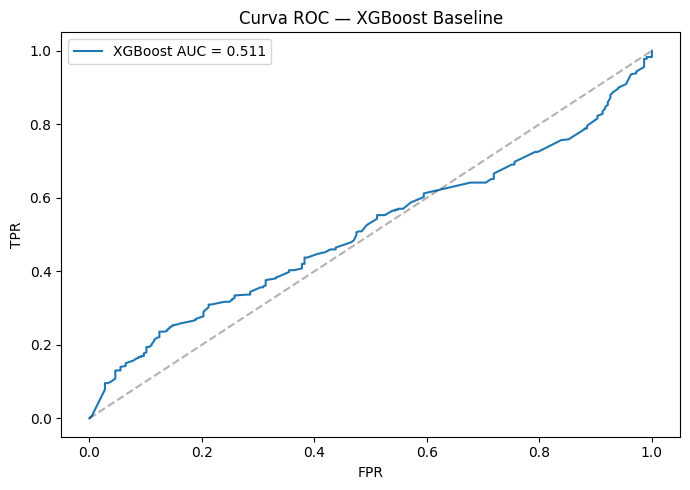

In [11]:
plot_roc(probs_xgb, y_test_xgb, save_path='xgboost_roc_17y.png')

12:26:46 [INFO] Gráficos salvos em transformer_17y.png


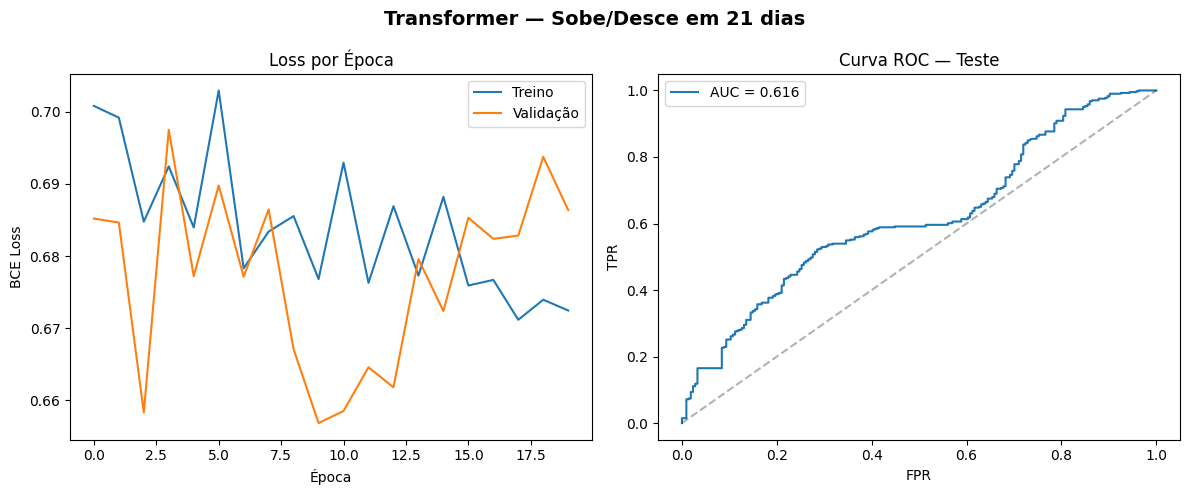

In [12]:
plot_transformer_results(hist_tf, probs_tf, y_test_tf, save_path='transformer_17y.png')

## 7. Resumo

In [13]:
print('RESUMO — ITUB4 com 17 anos de notícias')
print('=' * 60)
print(f'Artigos: {len(articles)}')
print(f'Dias com sentimento: {len(daily)}')
print(f'Dataset: {X_combined.shape}')
print(f'Sequências: {X_seq.shape}')
print(f'Balance: {y.mean():.1%} sobe / {1-y.mean():.1%} desce')
print()

for name, r in results.items():
    auc = roc_auc_score(r['y_test'], r['probs'])
    acc = accuracy_score(r['y_test'], r['preds'])
    f1 = f1_score(r['y_test'], r['preds'], zero_division=0)
    n_classes = len(set(r['preds']))
    disc = 'Sim' if n_classes > 1 else 'Não'
    print(f'{name}')
    print(f'  AUC: {auc:.4f} | Acc: {acc:.1%} | F1: {f1:.4f} | Discrimina: {disc}')

RESUMO — ITUB4 com 17 anos de notícias
Artigos: 12891
Dias com sentimento: 3807
Dataset: (4176, 16)
Sequências: (4125, 30, 16)
Balance: 56.9% sobe / 43.1% desce

BiLSTM Original (2L/128h)
  AUC: 0.5307 | Acc: 42.6% | F1: 0.2764 | Discrimina: Sim
BiLSTM Reduzido (1L/64h)
  AUC: 0.5215 | Acc: 37.7% | F1: 0.1147 | Discrimina: Sim
XGBoost
  AUC: 0.5113 | Acc: 34.8% | F1: 0.0000 | Discrimina: Não
Transformer
  AUC: 0.6160 | Acc: 39.2% | F1: 0.1490 | Discrimina: Sim
